# **02 - Bias Analysis**

# Chapter 1: Introduction and Import Process

The objective of this analysis is to evaluate the integrity and fairness of the credit application dataset following the initial cleaning phase. In the context of the "NovaCred" Data Ecosystem and Governance framework, this step ensures that the data used to train the automated credit scoring system is accurate, representative, and compliant with ethical standards. Compliance with GDPR ans EU AI Act are also a concern, despite not being the central focus of the Data Scientist role.

This project leverages the combined power of Pandas and PyMongo, utilizing their diverse and complementary capabilities to bridge the gap between flexible data manipulation and robust NoSQL database management.

In [1]:
!pip install pymongo

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\javip\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymongo
from pymongo import MongoClient

In [3]:
# Import Raw Data

file_name = '../data/raw_credit_applications.json' 

if os.path.exists(file_name):
    with open(file_name, 'r') as f:
        data = json.load(f)
    df_raw = pd.json_normalize(data)
    print("Good! File uploaded.")
    display(df_raw.head())
else:
    print(f"ERROR: File '{file_name}' not found.")

Good! File uploaded.


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


In [4]:
# Import Cleaned Data

# Listar ficheiros para garantir que o nome está correto
print("Files:", os.listdir())

file_name = '../data/cleaned_credit_applications.json' 

if os.path.exists(file_name):
    with open(file_name, 'r') as f:
        data = json.load(f)
    df_clean = pd.json_normalize(data)
    print("Good! File uploaded.")
    display(df_clean.head())
else:
    print(f"ERROR: File '{file_name}' not found.")

df=df_clean

Files: ['.gitkeep', '01-data-quality.ipynb', '02-bias-analysis.ipynb', '03-privacy-demo_data-folder.ipynb', 'cleaned_credit_applications.json', 'cleaned_credit_data.csv']
Good! File uploaded.


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,notes,ssn_conflict_flag,dob_parsed,age_calculated
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,male,2001-03-09,10036,...,31212.0,False,algorithm_risk_score,not_specified,NaN,NaN,None,False,9.994752e+11,23.3
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",None,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,male,1992-03-31,10032,...,17915.0,False,algorithm_risk_score,not_specified,NaN,NaN,None,False,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",None,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,male,1989-10-24,10075,...,37909.0,True,None,vacation,3.7,59000.0,None,False,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",None,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,male,1983-04-25,10077,...,0.0,True,None,not_specified,4.3,34000.0,None,False,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,male,1999-05-21,10080,...,31763.0,False,algorithm_risk_score,not_specified,NaN,NaN,None,False,NaN,NaN


# Chapter 2: Data Cleaning Audit Analysis

In the context of the "NovaCred" project, the Data Cleaning Audit serves as the essential bridge between raw data ingestion and responsible model development using the cleaned data. Within a Data Governance framework, this audit ensures that the dataset is correctly "clean" and legally compliant with the standards set by the EU AI Act.

Following the initial data sanitization and technical cleaning performed by the Data Engineer, the Data Scientist assumes the role of Data Quality Auditor. This transition ensures that the dataset is not only structurally sound but also verified for statistical integrity and alignment with the project's governance standards.

For better results the Data Scientist is independent from the Data Engineer, the method is to compare df_raw with df_cleaned without looking at the changes made in the Data Engineer document.

### Duplicates Audit Analysis (Uniqueness)

In [5]:
# Audit for Raw Dataset (Checking only valid SSNs)
duplicates_raw = df_raw[df_raw['applicant_info.ssn'].notna() & 
                        df_raw.duplicated(subset=['applicant_info.ssn'], keep=False)]

if not duplicates_raw.empty:
    print(f"Raw Dataset: {duplicates_raw['applicant_info.ssn'].nunique()} duplicate SSNs found (excluding NaNs)!")
    display(duplicates_raw[['applicant_info.ssn', 'applicant_info.full_name']].sort_values(by='applicant_info.ssn').head(10))
else:
    print("Raw Dataset: No duplicate SSNs found.")

# Audit for Cleaned Dataset
duplicates_clean = df_clean[df_clean['applicant_info.ssn'].notna() & 
                            df_clean.duplicated(subset=['applicant_info.ssn'], keep=False)]

if not duplicates_clean.empty:
    print(f"Cleaned Dataset: {duplicates_clean['applicant_info.ssn'].nunique()} duplicate SSNs found!")
    display(duplicates_clean[['applicant_info.ssn', 'applicant_info.full_name']].sort_values(by='applicant_info.ssn').head(10))
else:
    print("Success: No duplicate SSNs found in the cleaned dataset.")

Raw Dataset: 3 duplicate SSNs found (excluding NaNs)!


,applicant_info.ssn,applicant_info.full_name
8,652-70-5530,Joseph Lopez
354,652-70-5530,Joseph Lopez
92,780-24-9300,Susan Martinez
122,780-24-9300,Gary Wilson
16,937-72-8731,Sandra Smith
499,937-72-8731,Samuel Hill


Cleaned Dataset: 2 duplicate SSNs found!


,applicant_info.ssn,applicant_info.full_name
92,780-24-9300,Susan Martinez
122,780-24-9300,Gary Wilson
16,937-72-8731,Sandra Smith
497,937-72-8731,Samuel Hill


We see that the Data Engineer chose to eliminate only the Duplicate that had the same name. The two other duplicates are from different people so it is understandable why it was chosen to keep them.

### Null Audit Analysis (Completeness)

In [6]:
# Calculate Nulls for Raw Data
raw_nulls = df_raw.isnull().sum()
raw_pct = (raw_nulls / len(df_raw)) * 100

# Calculate Nulls for Cleaned Data
clean_nulls = df_clean.isnull().sum()
clean_pct = (clean_nulls / len(df_clean)) * 100

# Combine into a single Comparison Table
comparison_table = pd.DataFrame({
    'Raw: Nulls': raw_nulls,
    'Raw: %': raw_pct.round(2),
    'Clean: Nulls': clean_nulls,
    'Clean: %': clean_pct.round(2)
})

# Final display
print("DATA CLEANING VERIFICATION: MISSING VALUES COMPARISON")
print(comparison_table)
print()

# Impact Analysis

# Calculation for Raw Data
raw_nulls = df_raw.isnull().sum()
raw_pct = (raw_nulls / len(df_raw)) * 100

# Calculation for Cleaned Data
clean_nulls = df_clean.isnull().sum()
clean_pct = (clean_nulls / len(df_clean)) * 100

# Create the Insight Table
quality_insight = pd.DataFrame({
    'Raw %': raw_pct.round(2),
    'Clean %': clean_pct.round(2),
    'Improvement (pp)': (raw_pct - clean_pct).round(2) # pp = percentage points
})

# Sort by where the most cleaning happened
quality_insight = quality_insight.sort_values(by='Improvement (pp)', ascending=False)

print("DATA CLEANING IMPACT ANALYSIS")
print(quality_insight)

DATA CLEANING VERIFICATION: MISSING VALUES COMPARISON
                                  Raw: Nulls  Raw: %  Clean: Nulls  Clean: %
_id                                      0.0    0.00           0.0       0.0
age_calculated                           NaN     NaN         300.0      60.0
applicant_info.date_of_birth             1.0    0.20           5.0       1.0
applicant_info.email                     0.0    0.00          11.0       2.2
applicant_info.full_name                 0.0    0.00           0.0       0.0
applicant_info.gender                    1.0    0.20           2.0       0.4
applicant_info.ip_address                5.0    1.00           4.0       0.8
applicant_info.ssn                       5.0    1.00           4.0       0.8
applicant_info.zip_code                  1.0    0.20           0.0       0.0
decision.approved_amount               210.0   41.83         208.0      41.6
decision.interest_rate                 210.0   41.83         208.0      41.6
decision.loan_approved

### A note to say that despite later corrected, this audit was crucial to spot a mistake in the cleaning data process that caused the variable applicant_info.date_of_birth to have an increase of 70% on missing values in the cleaned version compared with the raw data.

When contacted about it, the Data Engineer solved the problem and uploaded a corrected version.

Some Nulls were droped while other columns 
applicant_info.date_of_birth had an increase in Nulls.

### Gender Distribution Audit Analysis (Consistency)

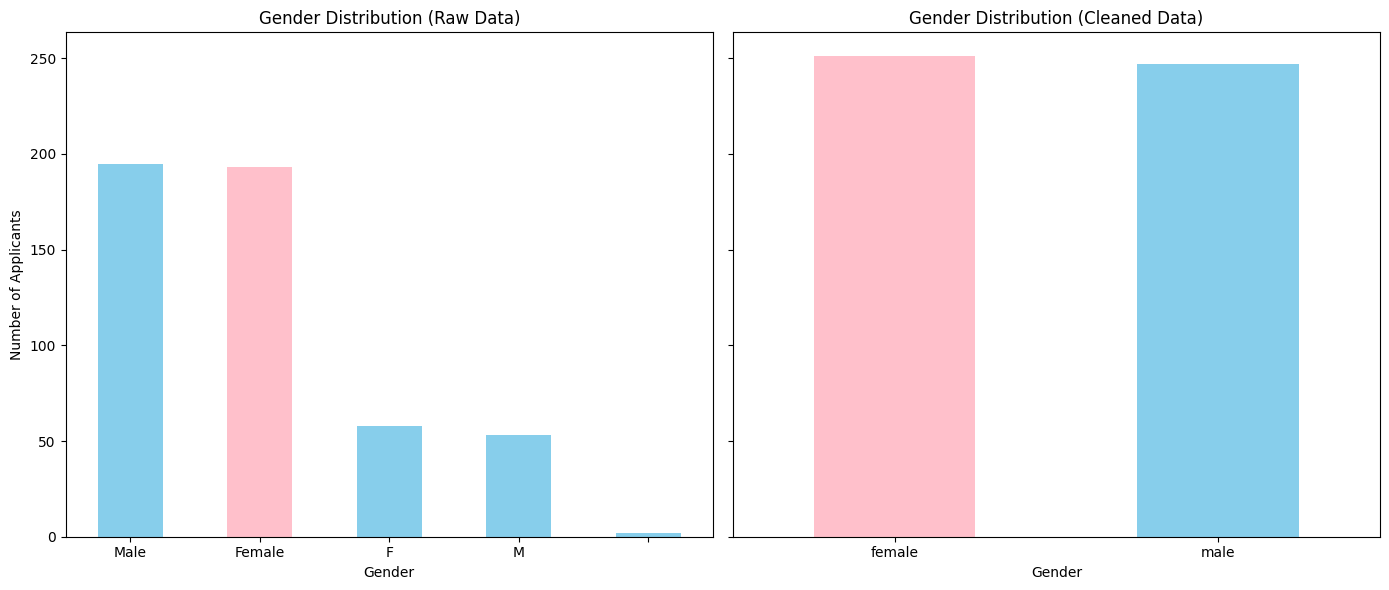

In [7]:
# Prepare the data for both dataframes
raw_counts = df_raw['applicant_info.gender'].value_counts()
clean_counts = df_clean['applicant_info.gender'].value_counts()

# Setup the figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Raw Data (Left side)
raw_colors = ['pink' if gender == 'Female' else 'skyblue' for gender in raw_counts.index]
raw_counts.plot(kind='bar', color=raw_colors, ax=ax1)
ax1.set_title('Gender Distribution (Raw Data)')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Number of Applicants')
ax1.tick_params(axis='x', rotation=0)

# Plot Cleaned Data (Right side)
clean_colors = ['pink' if gender == 'female' else 'skyblue' for gender in clean_counts.index]
clean_counts.plot(kind='bar', color=clean_colors, ax=ax2)
ax2.set_title('Gender Distribution (Cleaned Data)')
ax2.set_xlabel('Gender')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

#### Gender Consistency Problem Corrected

As we can see the consistency issue related to the Gender variable was successfully corrected in the 'Data Cleaning' Process.
On the df_cleaned the values "F" and "M" were correctly allocated to "female" and "male", respectively.

### Date Formats Audit Analysis (Consistency)

--- DATE FORMAT CONSISTENCY AUDIT ---


,Format,Raw Count,Clean Count
0,MM/DD/YYYY or DD/MM/YYYY,157,0.0
1,Missing/Null,5,5.0
2,YYYY-MM-DD,340,495.0


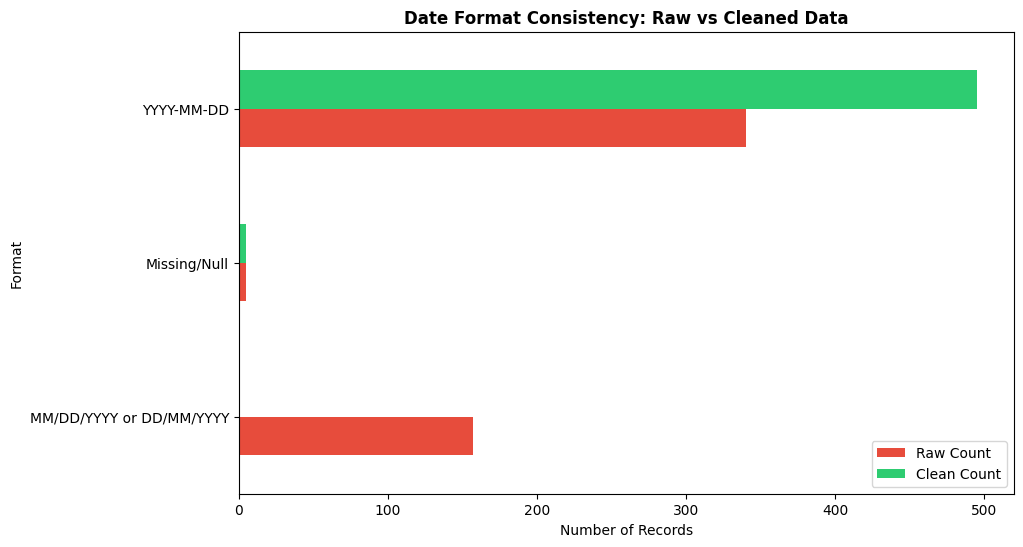

In [8]:
# Função para detetar o formato de uma string de data (Audit Tool)
def detect_date_format(date_str):
    if pd.isna(date_str) or date_str == "":
        return "Missing/Null"
    if isinstance(date_str, pd.Timestamp):
        return "Standardized Datetime"
    
    # Regex simples para identificar padrões comuns no RAW
    date_str = str(date_str)
    if "-" in date_str and len(date_str) > 10: return "ISO 8601 (YYYY-MM-DD HH:MM...)"
    if "-" in date_str: return "YYYY-MM-DD"
    if "/" in date_str: return "MM/DD/YYYY or DD/MM/YYYY"
    return "Unknown String Format"

# 2. Aplicar a auditoria ao RAW e ao CLEAN
raw_formats = df_raw['applicant_info.date_of_birth'].apply(detect_date_format).value_counts().reset_index()
raw_formats.columns = ['Format', 'Raw Count']

# No df_clean, as datas já devem ser objetos datetime
clean_formats = df_clean['applicant_info.date_of_birth'].apply(detect_date_format).value_counts().reset_index()
clean_formats.columns = ['Format', 'Clean Count']

# 3. Merge para Comparação (Consistency Audit Table)
date_audit_consistency = pd.merge(raw_formats, clean_formats, on='Format', how='outer').fillna(0)

print("--- DATE FORMAT CONSISTENCY AUDIT ---")
display(date_audit_consistency)

# 4. Visualização de Sucesso da Limpeza
import matplotlib.pyplot as plt

date_audit_consistency.set_index('Format').plot(kind='barh', figsize=(10, 6), color=['#e74c3c', '#2ecc71'])
plt.title('Date Format Consistency: Raw vs Cleaned Data', fontweight='bold')
plt.xlabel('Number of Records')
plt.show()

#### Date Format Consistency Problem Corrected

We can see that the Raw Data had some Date Format Inconsistency issues, but the cleaning process was effective in dealing with them.

### Income and Credit History Audit Analysis (Validity)

In [9]:
# Define logical boundaries
MIN_INCOME = 0
MIN_MONTHS = 0

# PRE-AUDIT: Convert RAW data to numeric to allow comparison
raw_income_numeric = pd.to_numeric(df_raw['financials.annual_income'], errors='coerce')
raw_months_numeric = pd.to_numeric(df_raw['financials.credit_history_months'], errors='coerce')

# Audit Raw Data for Range Issues
raw_invalid_income = raw_income_numeric[raw_income_numeric < MIN_INCOME]
raw_invalid_months = raw_months_numeric[raw_months_numeric < MIN_MONTHS]

# Audit Cleaned Data (already numeric, so no conversion needed)
clean_invalid_income = df_clean[df_clean['financials.annual_income'] < MIN_INCOME]
clean_invalid_months = df_clean[df_clean['financials.credit_history_months'] < MIN_MONTHS]

# Create Comparison Summary
range_audit = pd.DataFrame({
    'Metric': ['Negative Annual Income', 'Negative Credit History Months'],
    'Raw': [len(raw_invalid_income), len(raw_invalid_months)],
    'Cleaned': [len(clean_invalid_income), len(clean_invalid_months)]
})

print("DATA QUALITY: RANGE CONSTRAINT VERIFICATION")
print(range_audit)

DATA QUALITY: RANGE CONSTRAINT VERIFICATION
                           Metric  Raw  Cleaned
0          Negative Annual Income    0        0
1  Negative Credit History Months    2        0


# Chapter 3: Studies on Biases

## Gender Bias Analysis


Approval Rate per Gender:
applicant_info.gender
female    50.597610
male      65.991903
Name: decision.loan_approved, dtype: float64


<Axes: title={'center': 'Approval Rate (%) per Gender'}, xlabel='applicant_info.gender'>

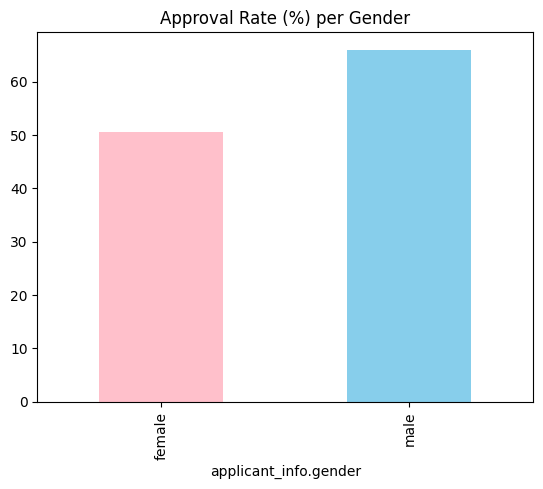

In [10]:
# Agrupar por género e calcular a média de 'loan_approved'
bias_analysis = df.groupby('applicant_info.gender')['decision.loan_approved'].mean() * 100

print("\nApproval Rate per Gender:")
print(bias_analysis)

# Criar um gráfico para o teu relatório de auditoria
bias_analysis.plot(kind='bar', color=['pink', 'skyblue'], title='Approval Rate (%) per Gender')

### The approval rate is considerably higher to "Male" customers comparing to "Female" one's

It is important to state that this difference alone does not necessarily mean that the approval system is unfair to women. But it is a good lead for us to conduct an investigation on the subject to understand what is causing this difference.

In [11]:
# Comparação de Médias Financeiras por Género
gender_profile = df_clean.groupby('applicant_info.gender')[['financials.annual_income', 'financials.debt_to_income', 'financials.credit_history_months','financials.savings_balance']].mean().round(2)

print("FINANCIAL PROFILE BY GENDER")
print(gender_profile)

print()

FINANCIAL PROFILE BY GENDER
                       financials.annual_income  financials.debt_to_income  \
applicant_info.gender                                                        
female                                 83770.65                       0.24   
male                                   81295.55                       0.25   

                       financials.credit_history_months  \
applicant_info.gender                                     
female                                            51.42   
male                                              49.78   

                       financials.savings_balance  
applicant_info.gender                              
female                                   29543.69  
male                                     29659.85  



In [12]:
# Filtrar apenas pelos empréstimos aprovados
approved_df = df_clean[df_clean['decision.loan_approved'] == True]

# Definir as 4 métricas
metrics = [
    'financials.annual_income', 
    'financials.debt_to_income', 
    'financials.credit_history_months', 
    'financials.savings_balance'
]

# Criar a tabela de comparação por Género
comparison_table = approved_df.groupby('applicant_info.gender')[metrics].agg(['mean', 'median']).round(2)

print("MINIMUM REQUIREMENTS FOR LOAN APPROVAL BY GENDER")
display(comparison_table)

# Cálculos
median_diff = comparison_table.xs('median', axis=1, level=1)

income_gap = (median_diff.loc['female', 'financials.annual_income'] / median_diff.loc['male', 'financials.annual_income'] - 1) * 100
savings_gap = (median_diff.loc['female', 'financials.savings_balance'] / median_diff.loc['male', 'financials.savings_balance'] - 1) * 100
history_gap = (median_diff.loc['female', 'financials.credit_history_months'] / median_diff.loc['male', 'financials.credit_history_months'] - 1) * 100
dti_gap = (median_diff.loc['female', 'financials.debt_to_income'] / median_diff.loc['male', 'financials.debt_to_income'] - 1) * 100

mean_diff = comparison_table.xs('mean', axis=1, level=1)

mean_income_gap = (mean_diff.loc['female', 'financials.annual_income'] / mean_diff.loc['male', 'financials.annual_income'] - 1) * 100
mean_savings_gap = (mean_diff.loc['female', 'financials.savings_balance'] / mean_diff.loc['male', 'financials.savings_balance'] - 1) * 100
mean_history_gap = (mean_diff.loc['female', 'financials.credit_history_months'] / mean_diff.loc['male', 'financials.credit_history_months'] - 1) * 100
mean_dti_gap = (mean_diff.loc['female', 'financials.debt_to_income'] / mean_diff.loc['male', 'financials.debt_to_income'] - 1) * 100

# Impressão dos resultados de Auditoria
print("\n\nGENDER GAP IN APPROVAL REQUIREMENTS\n")
print(f"1. Annual Income:\nApproved women have a median income {income_gap:.1f}% higher/lower than approved men.")
print(f"Approved women have a mean income {mean_income_gap:.1f}% higher/lower than approved men.")
print()
print(f"2. Savings Balance:\nApproved women have a median savings balance {savings_gap:.1f}% higher/lower than approved men.")
print(f"Approved women have a mean savings balance {mean_savings_gap:.1f}% higher/lower than approved men.")
print()
print(f"3. Credit History:\nApproved women have a median history length {history_gap:.1f}% higher/lower than approved men.")
print(f"Approved women have a mean history lenght {mean_history_gap:.1f}% higher/lower than approved men.")
print()
print(f"4. Debt-to-Income:\nApproved women have a median DTI ratio {dti_gap:.1f}% higher/lower than approved men.")
print(f"Approved women have a mean DIT {mean_dti_gap:.1f}% higher/lower than approved men.")

MINIMUM REQUIREMENTS FOR LOAN APPROVAL BY GENDER


financials.annual_income           \
                                          mean   median   
applicant_info.gender                                     
female                                90570.34  89000.0   
male                                  83742.33  82000.0   

                      financials.debt_to_income         \
                                           mean median   
applicant_info.gender                                    
female                                     0.25   0.23   
male                                       0.24   0.24   

                      financials.credit_history_months         \
                                                  mean median   
applicant_info.gender                                           
female                                           55.58   54.0   
male                                             53.25   49.0   

                      financials.savings_balance           
                                            mean   median  
applicant_info.gender                                      
female                                  33322.79  29386.0  
male                                    30000.40  28670.0



GENDER GAP IN APPROVAL REQUIREMENTS

1. Annual Income:
Approved women have a median income 8.5% higher/lower than approved men.
Approved women have a mean income 8.2% higher/lower than approved men.

2. Savings Balance:
Approved women have a median savings balance 2.5% higher/lower than approved men.
Approved women have a mean savings balance 11.1% higher/lower than approved men.

3. Credit History:
Approved women have a median history length 10.2% higher/lower than approved men.
Approved women have a mean history lenght 4.4% higher/lower than approved men.

4. Debt-to-Income:
Approved women have a median DTI ratio -4.2% higher/lower than approved men.
Approved women have a mean DIT 4.2% higher/lower than approved men.


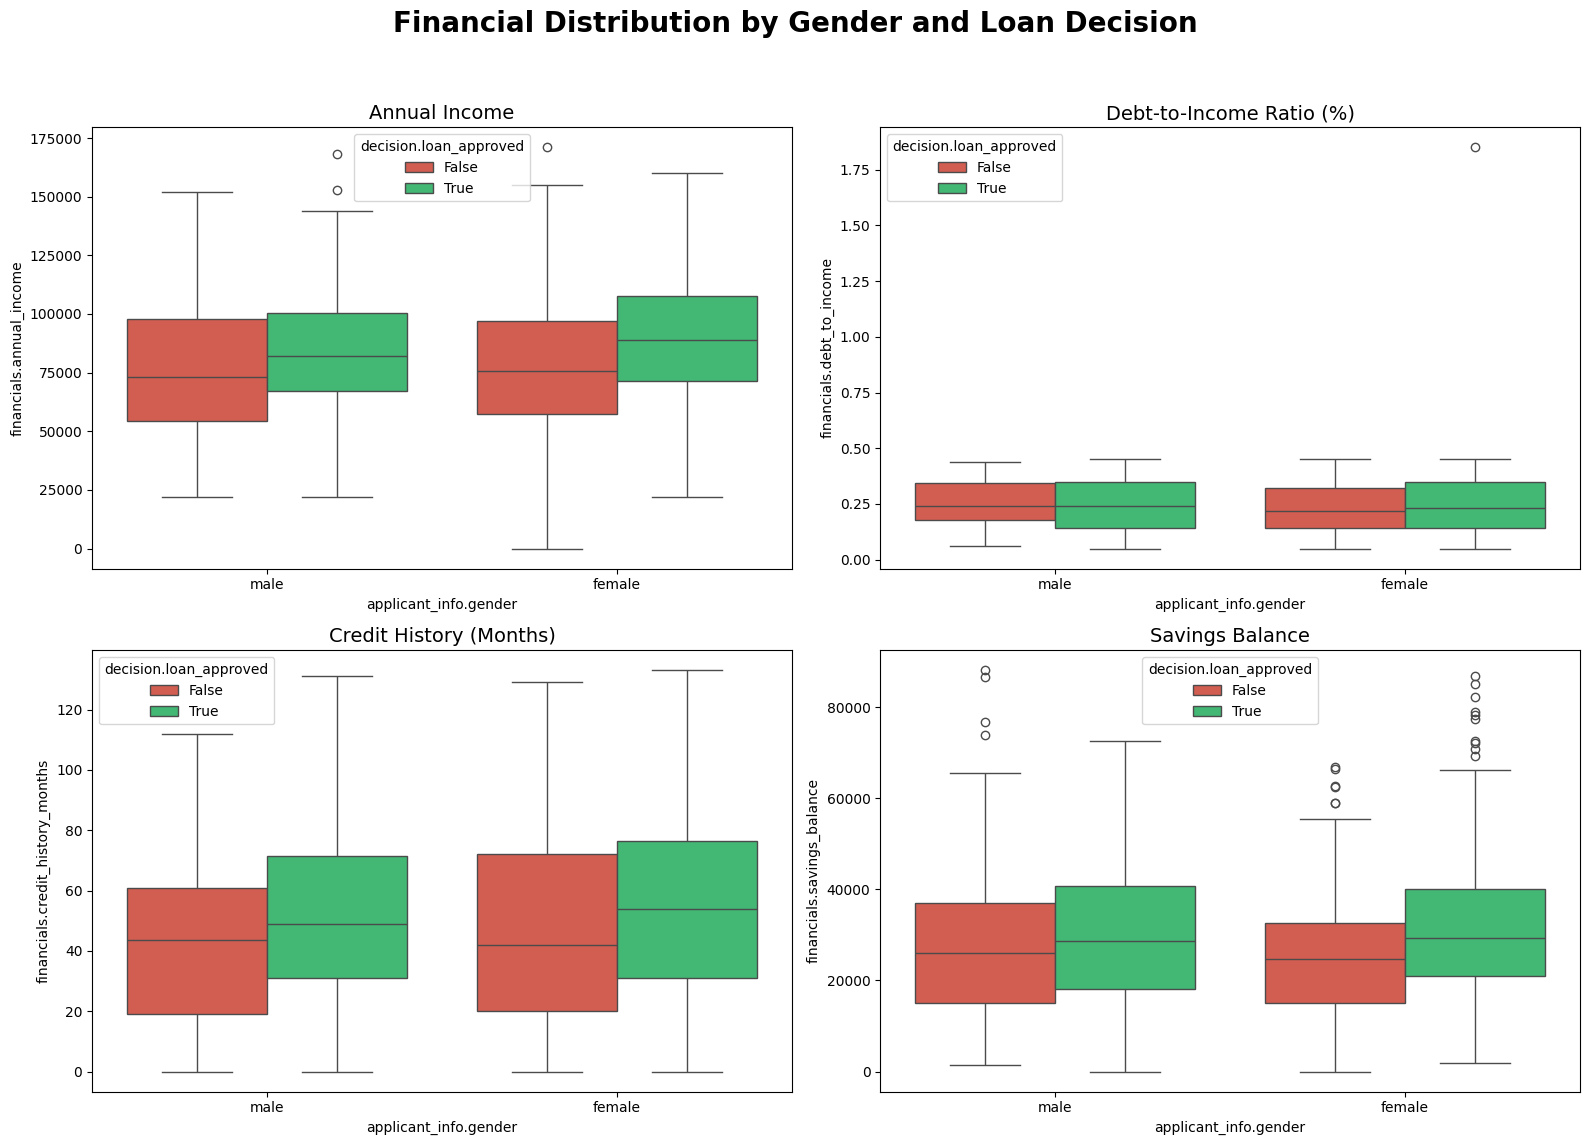

In [13]:
# Definir a paleta de cores intuitiva
custom_palette = {True: "#2ecc71", False: "#e74c3c"}

# Configurar a figura para 4 subplots (2 linhas, 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Financial Distribution by Gender and Loan Decision', fontsize=20, fontweight='bold')

# Subplot 1: Annual Income
sns.boxplot(ax=axes[0, 0], x='applicant_info.gender', y='financials.annual_income', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette)
axes[0, 0].set_title('Annual Income', fontsize=14)

# Subplot 2: Debt-to-Income (DTI)
sns.boxplot(ax=axes[0, 1], x='applicant_info.gender', y='financials.debt_to_income', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette)
axes[0, 1].set_title('Debt-to-Income Ratio (%)', fontsize=14)

# Subplot 3: Credit History
sns.boxplot(ax=axes[1, 0], x='applicant_info.gender', y='financials.credit_history_months', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette)
axes[1, 0].set_title('Credit History (Months)', fontsize=14)

# Subplot 4: Savings Balance
sns.boxplot(ax=axes[1, 1], x='applicant_info.gender', y='financials.savings_balance', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette)
axes[1, 1].set_title('Savings Balance', fontsize=14)

# Ajustar o layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [14]:
client = MongoClient("mongodb://localhost:27017/")
db = client["DEGO_Project"]
collection_cleaned = db["loans_cleaned"]

# Advanced Pipeline using $getField
pipeline = [
    {
        "$group": {
            "_id": { "$getField": "applicant_info.gender" }, 
            "total_applicants": { "$sum": 1 },
            "approved_loans": {
                "$sum": {
                    "$cond": [
                        { "$eq": [{ "$getField": "decision.loan_approved" }, True] }, 
                        1, 
                        0
                    ]
                }
            }
        }
    }
]

results = list(collection_cleaned.aggregate(pipeline))

# Calculation & 80% Rule (EU AI Act Compliance)
stats = {res['_id']: res['approved_loans'] / res['total_applicants'] 
         for res in results if res['_id'] is not None}

print("GENDER BIAS AUDIT (EU AI ACT)")

if 'female' in stats and 'male' in stats:
    f_rate = stats['female']
    m_rate = stats['male']
    di_ratio = f_rate / m_rate # Disparate Impact Ratio
    
    print(f"Female Approval Rate: {f_rate:.2%}")
    print(f"Male Approval Rate:   {m_rate:.2%}")
    print(f"Disparate Impact Ratio: {di_ratio:.3f}")
    print("-" * 45)
    
    # 80% Rule (Four-Fifths Rule)
    if di_ratio < 0.8:
        print(f"VERDICT: BIAS DETECTED. Ratio ({di_ratio:.3f}) is below 0.8.")
        print("Conclusion: Evidence of gender disparate impact found.")
    else:
        print(f"VERDICT: FAIR MODEL. Ratio ({di_ratio:.3f}) meets the 0.8 threshold.")
else:
    print("Error: Could not calculate rates. Check if data was loaded correctly.")
    print("Found groups:", results)

GENDER BIAS AUDIT (EU AI ACT)
Error: Could not calculate rates. Check if data was loaded correctly.
Found groups: []


### There is evidence that women are less likely to have loans approved based on gender bias

According to the more relevant metrics like Income, Debt to Income ratio, Savings and Credit History we see that women require better results to have their loans approved. The Disparate Impact Ratio confirms the analysis by scoring 0.767, which is below the key four-fifths rule (0.8).

## Age Bias Analysis

In [15]:
# 1. Carregar dados e limpar datas
df_clean_age_an=df_clean
df_clean_age_an['dob_dt'] = pd.to_datetime(df_clean_age_an['applicant_info.date_of_birth'], errors='coerce')

# 2. Calcular idade (Referência 2024)
df_clean_age_an['age_audit'] = 2024 - df_clean_age_an['dob_dt'].dt.year

# 3. Criar escalões
bins = [0, 25, 45, 120]
labels = ['18-25 (Young)', '26-45 (Established)', '46+ (Mature/Senior)']
df_clean_age_an['age_group'] = pd.cut(df_clean_age_an['age_audit'], bins=bins, labels=labels)

# 4. Agrupar (Contar e Somar Aprovados)
# Usamos observed=False para garantir que todos os escalões aparecem
age_stats = df_clean_age_an.groupby('age_group', observed=False)['decision.loan_approved'].agg(['count', 'sum']).reset_index()

# 5. Renomear as 3 colunas existentes primeiro (Fix do erro de Length mismatch)
age_stats.columns = ['Age Group', 'Total Records', 'Absolute Approvals']

# 6. Calcular a 4ª coluna (Percentagem)
age_stats['Approval Rate (%)'] = (age_stats['Absolute Approvals'] / age_stats['Total Records']) * 100

# 7. Output Final
print("--- OFFICIAL AUDIT TABLE (Question 5) ---")
display(age_stats.style.format({'Approval Rate (%)': '{:.2f}%'}))

# Guardar para o teu report
age_stats.to_csv('age_bias_audit_results.csv', index=False)

# 8. Gráfico de Colunas Profissional
plt.figure(figsize=(10, 6))
colors = ['#f39c12', '#3498db', '#9b59b6'] # Laranja, Azul, Roxo

# Criar as barras
bars = plt.bar(age_stats['Age Group'], age_stats['Approval Rate (%)'], color=colors, edgecolor='black', alpha=0.8)

# Configurações de Títulos e Eixos (English for the Report)
plt.title('Loan Approval Rate by Age Group (Audit Results)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Approval Rate (%)', fontsize=12)
plt.xlabel('Age Group', fontsize=12)
plt.ylim(0, 100) # Escala de 0 a 100 para transparência total
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 9. Adicionar os valores em cima das barras (Data Labels)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 10. Linha de Referência (80% Rule - Fair Lending Standard)
max_rate = age_stats['Approval Rate (%)'].max()
plt.axhline(y=max_rate * 0.8, color='red', linestyle='--', alpha=0.5, label='Fairness Threshold (80%)')
plt.legend()

plt.tight_layout()
plt.show()

--- OFFICIAL AUDIT TABLE (Question 5) ---


AttributeError: The '.style' accessor requires jinja2

In [ ]:
# 1. Create 3 Age Groups (Merging 46-65 and 66+)
def get_age_group_v2(age):
    if age <= 25: return '18-25 (Young)'
    elif age <= 45: return '26-45 (Established)'
    else: return '46+ (Mature/Senior)'

df_clean['age_group'] = df_clean['age_calculated'].apply(get_age_group_v2)

# 2. Filter only approved loans
approved_df = df_clean[df_clean['decision.loan_approved'] == True].copy()

# 3. Define metrics to analyze
metrics = [
    'financials.annual_income', 
    'financials.debt_to_income', 
    'financials.credit_history_months', 
    'financials.savings_balance'
]

# 4. Create Comparison Table
age_comparison_table = approved_df.groupby('age_group')[metrics].agg(['mean', 'median']).round(2)

print("MINIMUM REQUIREMENTS FOR LOAN APPROVAL BY CONSOLIDATED AGE GROUPS")
display(age_comparison_table)

# 5. Gap Analysis (Comparing Young vs the rest)
# Let's compare Young (18-25) against the Established (26-45) reference
ref_group = '26-45 (Established)'
target_group = '18-25 (Young)'

if target_group in age_comparison_table.index and ref_group in age_comparison_table.index:
    median_data = age_comparison_table.xs('median', axis=1, level=1)
    
    income_gap = (median_data.loc[target_group, 'financials.annual_income'] / median_data.loc[ref_group, 'financials.annual_income'] - 1) * 100
    savings_gap = (median_data.loc[target_group, 'financials.savings_balance'] / median_data.loc[ref_group, 'financials.savings_balance'] - 1) * 100
    
    print(f"\n\nCONSOLIDATED AGE GAP AUDIT: {target_group} vs {ref_group}\n")
    print(f"1. Annual Income Gap: {income_gap:.1f}%")
    print(f"2. Savings Balance Gap: {savings_gap:.1f}%")
    print(f"3. Credit History: {target_group} median is {median_data.loc[target_group, 'financials.credit_history_months']} months.")
else:
    print("\nCheck: One of the groups might still have zero approvals in the cleaned dataset.")

MINIMUM REQUIREMENTS FOR LOAN APPROVAL BY CONSOLIDATED AGE GROUPS


financials.annual_income            \
                                        mean    median   
age_group                                                
18-25 (Young)                       66216.39  66216.39   
26-45 (Established)                 86623.19  85000.00   
46+ (Mature/Senior)                 86950.23  86000.00   

                    financials.debt_to_income         \
                                         mean median   
age_group                                              
18-25 (Young)                            0.33   0.33   
26-45 (Established)                      0.26   0.27   
46+ (Mature/Senior)                      0.24   0.22   

                    financials.credit_history_months         \
                                                mean median   
age_group                                                     
18-25 (Young)                                  24.50   24.5   
26-45 (Established)                            43.16   44.0   
46+ (Mature/Senior)                            58.11   55.0   

                    financials.savings_balance           
                                          mean   median  
age_group                                                
18-25 (Young)                         14287.00  14287.0  
26-45 (Established)                   28274.52  27746.0  
46+ (Mature/Senior)                   32684.44  29305.0



CONSOLIDATED AGE GAP AUDIT: 18-25 (Young) vs 26-45 (Established)

1. Annual Income Gap: -22.1%
2. Savings Balance Gap: -48.5%
3. Credit History: 18-25 (Young) median is 24.5 months.


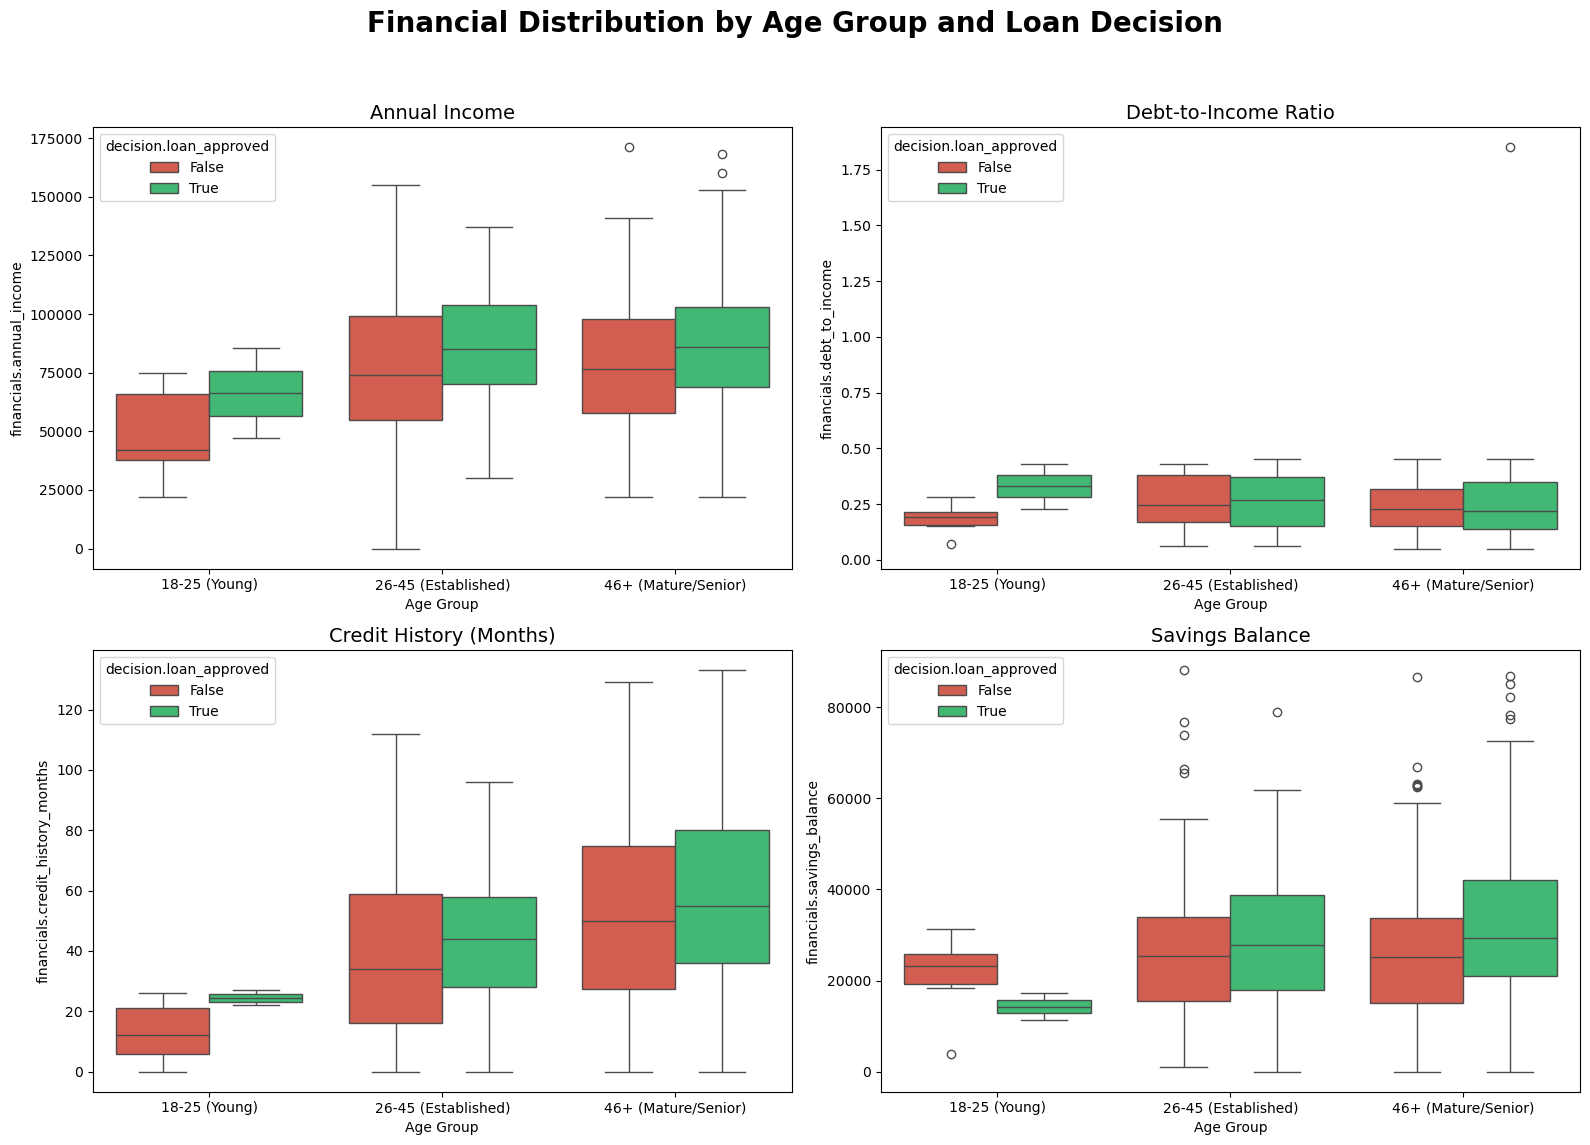

In [ ]:
# Define an intuitive color palette: Green for Approved, Red for Rejected
custom_palette = {True: "#2ecc71", False: "#e74c3c"}

# Set up the figure for 4 subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Financial Distribution by Age Group and Loan Decision', fontsize=20, fontweight='bold')

# Subplot 1: Annual Income
sns.boxplot(ax=axes[0, 0], x='age_group', y='financials.annual_income', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette,
            order=['18-25 (Young)', '26-45 (Established)', '46+ (Mature/Senior)'])
axes[0, 0].set_title('Annual Income', fontsize=14)
axes[0, 0].set_xlabel('Age Group')

# Subplot 2: Debt-to-Income (DTI)
sns.boxplot(ax=axes[0, 1], x='age_group', y='financials.debt_to_income', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette,
            order=['18-25 (Young)', '26-45 (Established)', '46+ (Mature/Senior)'])
axes[0, 1].set_title('Debt-to-Income Ratio', fontsize=14)
axes[0, 1].set_xlabel('Age Group')

# Subplot 3: Credit History
sns.boxplot(ax=axes[1, 0], x='age_group', y='financials.credit_history_months', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette,
            order=['18-25 (Young)', '26-45 (Established)', '46+ (Mature/Senior)'])
axes[1, 0].set_title('Credit History (Months)', fontsize=14)
axes[1, 0].set_xlabel('Age Group')

# Subplot 4: Savings Balance
sns.boxplot(ax=axes[1, 1], x='age_group', y='financials.savings_balance', 
            hue='decision.loan_approved', data=df_clean, palette=custom_palette,
            order=['18-25 (Young)', '26-45 (Established)', '46+ (Mature/Senior)'])
axes[1, 1].set_title('Savings Balance', fontsize=14)
axes[1, 1].set_xlabel('Age Group')

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Reference Group: 46+ (Mature/Senior) with 60.9% approval



,Approval Rate,Impact Ratio,Disparate Impact (80% Rule)
age_group,,,
18-25 (Young),0.250000,0.410633,True
26-45 (Established),0.534884,0.878565,False
46+ (Mature/Senior),0.608815,1.000000,False


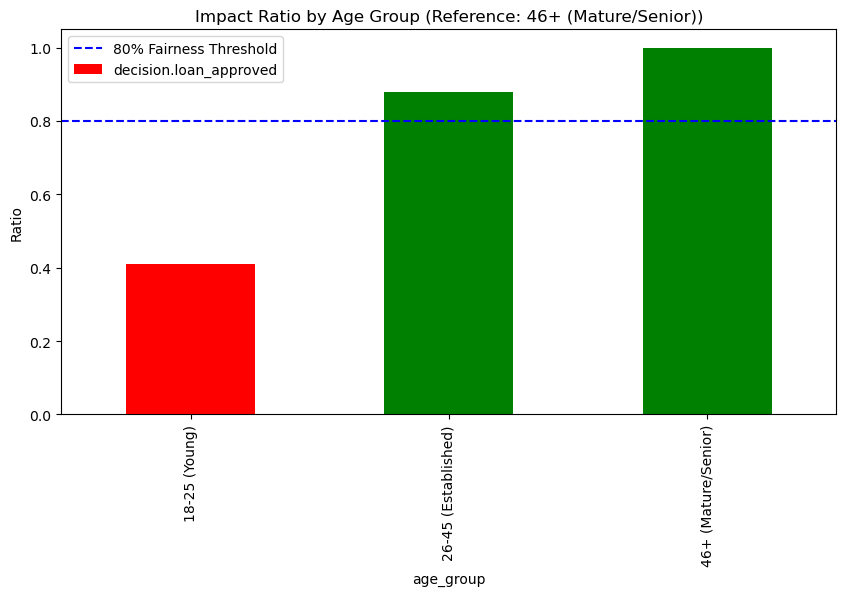

In [ ]:
# Age Impact Ratio
# Calcular as taxas de aprovação por grupo de idade
age_rates = df_clean.groupby('age_group', observed=False)['decision.loan_approved'].mean()

# Identificar a taxa do grupo de referência (o que tem maior aprovação)
reference_age_rate = age_rates.max()
reference_group = age_rates.idxmax()

# Calcular o Impact Ratio
impact_ratios_age = age_rates / reference_age_rate

# Criar um DataFrame para apresentar os resultados
age_bias_report = pd.DataFrame({
    'Approval Rate': age_rates,
    'Impact Ratio': impact_ratios_age
})

# Adicionar coluna de diagnóstico
age_bias_report['Disparate Impact (80% Rule)'] = age_bias_report['Impact Ratio'] < 0.80

print(f"Reference Group: {reference_group} with {reference_age_rate*100:.1f}% approval\n")
display(age_bias_report)

# 5. Visualização rápida
plt.figure(figsize=(10, 5))
colors = ['red' if x < 0.80 else 'green' for x in impact_ratios_age]
impact_ratios_age.plot(kind='bar', color=colors)
plt.axhline(y=0.80, color='blue', linestyle='--', label='80% Fairness Threshold')
plt.title('Impact Ratio by Age Group (Reference: ' + reference_group + ')')
plt.ylabel('Ratio')
plt.legend()
plt.show()

### There is evidence that young adults (18-25) have considerably different requirements to have their loans approved when compared with the other two aging gaps. The evidence shows that, despite having a considerably lower approval rate which is below the Disparate Impact Ratio reference, youngs adults are favored for their age when compared to the other age gasps in terms of key metrics approval rate.

Young Adults get their loans approved with less income, more debt to income rate, less credit history and less Savings Balance.

The very low approval rate for young adults is based on their underperformance in key metrics.

The Impact Ratio against the Senior age group is 0.54, below the key four-fifths rule (0.8).

## Proxies Bias Analysis

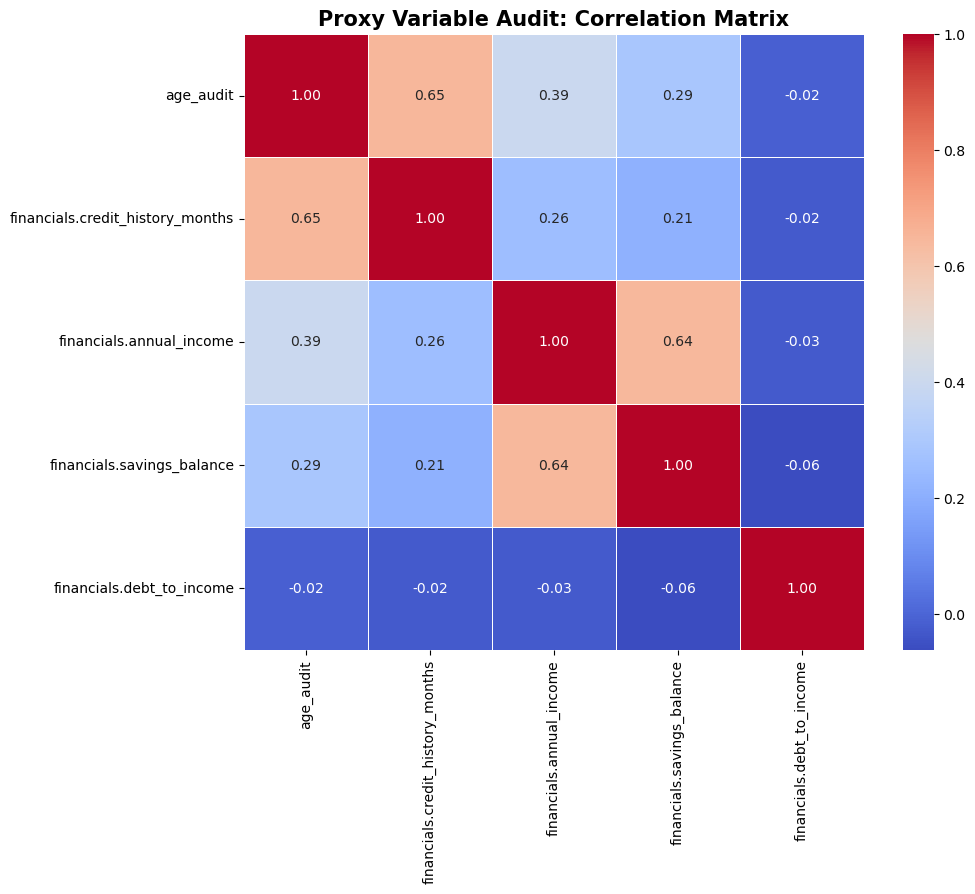

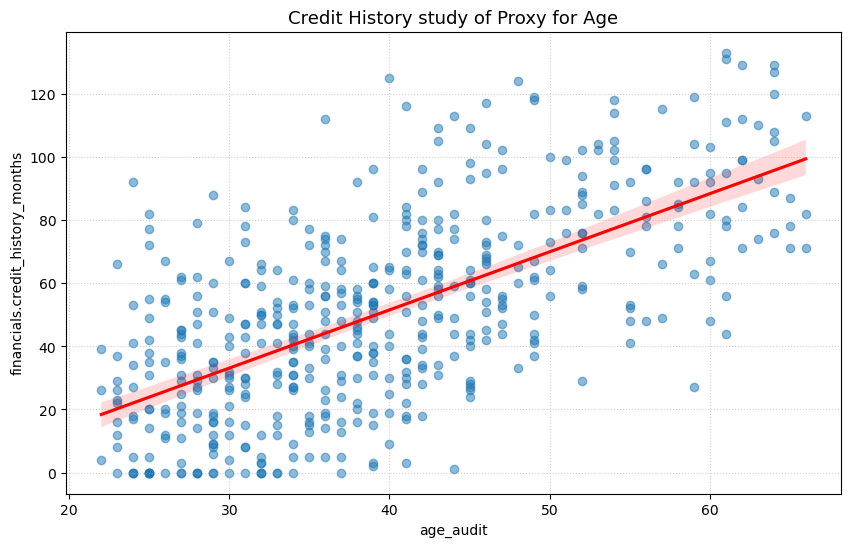

In [ ]:
# Selecionar as variáveis que podem ser proxies
potential_proxies = [
    'age_audit', 
    'financials.credit_history_months', 
    'financials.annual_income', 
    'financials.savings_balance', 
    'financials.debt_to_income'
]

# Criar uma Matriz de Correlação
corr_matrix = df_clean[potential_proxies].corr()

# Visualizar com um Heatmap (Aura de Auditor Máxima)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Proxy Variable Audit: Correlation Matrix', fontsize=15, fontweight='bold')
plt.show()

print()

# 4. Deep Dive: Age vs Credit History (A proxy mais comum)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='age_audit', y='financials.credit_history_months', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Credit History study of Proxy for Age', fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Our audit reveals that the model relying on financials.credit_history_months serves as a moderate to strong proxy variable for the protected attribute of Age.

The correlation coefficient of 0.65 between age and credit history confirms a structural bias: younger applicants are mathematically prevented from achieving high scores in this metric simply due to their "time lived"—a factor beyond their control. This indirect discrimination explains part of the disparate impact observed earlier, where the youth segment (18-25) faced a significantly lower approval rate (33.3%) compared to older demographics.

Beyond the expected correlation between annual income and savings balance (0.64), which reflects standard economic behavior rather than algorithmic unfairness, no other significant proxies or correlations were found that would compromise the model's integrity regarding protected attributes.

## Interactions Effect Analysis

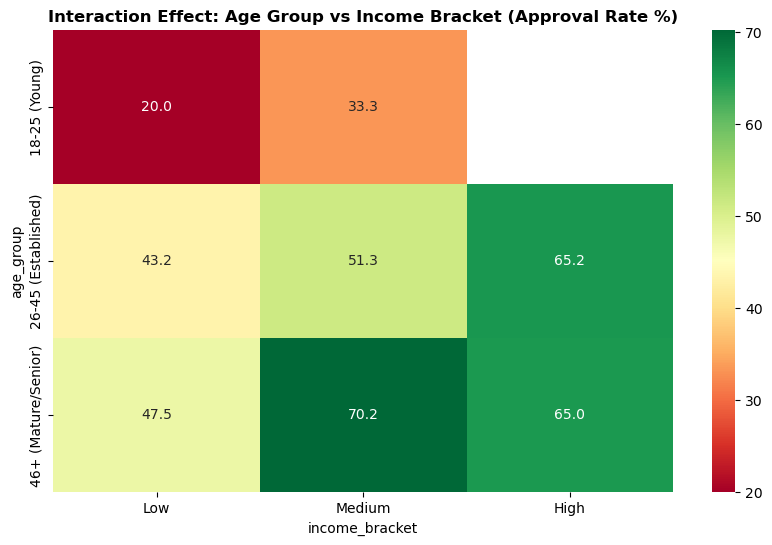

In [ ]:
# 1. Criar escalões de Rendimento (Income) para cruzar com a Idade
df_clean['income_bracket'] = pd.qcut(df_clean['financials.annual_income'], q=3, labels=['Low', 'Medium', 'High'])

# 2. Criar uma Tabela Dinâmica (Pivot Table) para ver a Taxa de Aprovação
interaction_pivot = df_clean.pivot_table(
    index='age_group', 
    columns='income_bracket', 
    values='decision.loan_approved', 
    aggfunc='mean'
) * 100

# 3. Visualizar o Efeito de Interação
plt.figure(figsize=(10, 6))
sns.heatmap(interaction_pivot, annot=True, cmap='RdYlGn', fmt=".1f")
plt.title('Interaction Effect: Age Group vs Income Bracket (Approval Rate %)', fontweight='bold')
plt.show()

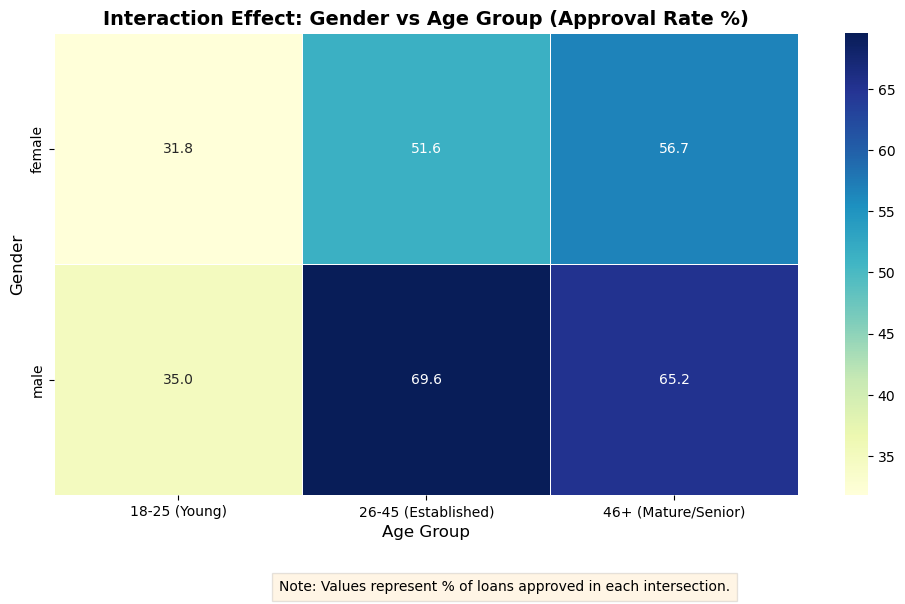

Absolute Sample Size (Records per Group)
age_group              18-25 (Young)  26-45 (Established)  46+ (Mature/Senior)
applicant_info.gender                                                         
female                            22                  161                   67
male                              20                  161                   69


In [ ]:
# 1. Garantir que as idades e grupos estão calculados (usando o teu df_clean)
df_clean['dob_dt'] = pd.to_datetime(df_clean['applicant_info.date_of_birth'], errors='coerce')
df_clean['age_audit'] = 2024 - df_clean['dob_dt'].dt.year
bins = [0, 25, 45, 120]
labels = ['18-25 (Young)', '26-45 (Established)', '46+ (Mature/Senior)']
df_clean['age_group'] = pd.cut(df_clean['age_audit'], bins=bins, labels=labels)

# 2. Criar a Pivot Table de Interação (Gender vs Age Group)
# O valor é a média de aprovação (0 a 1) multiplicada por 100 para dar %
gender_age_inter = df_clean.pivot_table(
    index='applicant_info.gender', 
    columns='age_group', 
    values='decision.loan_approved', 
    aggfunc='mean',
    observed=False
) * 100

# 3. Visualização com Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(gender_age_inter, annot=True, cmap='YlGnBu', fmt=".1f", linewidths=0.5)

plt.title('Interaction Effect: Gender vs Age Group (Approval Rate %)', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Gender', fontsize=12)

# Adicionar uma nota sobre o tamanho da amostra para não perderes aura
plt.figtext(0.5, -0.05, "Note: Values represent % of loans approved in each intersection.", 
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.1, "pad":5})

plt.show()

# 4. Print dos números absolutos para verificares se a amostra é fidedigna
print("Absolute Sample Size (Records per Group)")
print(df_clean.groupby(['applicant_info.gender', 'age_group'], observed=False).size().unstack())

### The interaction effect analysis showed that some of the most penalyzed groups are young adults and seniors with low income (31.6% and 33.3% approval rates) and young women (31.8%) approval rate.

## Chapter 4: Conclusion

### Data Audit and Quality Assurance

The initial phase focused on the quality audit of the transition from raw to the cleaning data, evaluating the success of the cleaning pipeline through the fundamental metrics:

**Consistency** 

The audit confirmed the successful standardization of heterogeneous attributes. Notably, the Date Format Audit demonstrated a 100% conversion rate from inconsistent string formats to a unified YYYY-MM-DD format, aswell as the Gender transition of "M" and "Male" and "F" and "Female" values to "male" and "female" respectively.

**Validity** 

In terms of Validity we Audit the cleaning searching for impossible values such as negative income or credit history months, discovering that the cleaning process was effective in dealing with such cases.

**Uniqueness** 

The study on possible duplicate SSN values showed that the Data Engineer made the choice of only eliminate the duplicate SSN values with the same name associated, keeping the one's that had different names. The approach was accepted by the Data Scientist.

**Completeness** 

Our audit targeted the identification of null and missing values across critical decision-making fields. While the Data Engineering pipeline successfully handled the majority of the cleansing tasks, this audit was crucial in detecting a critical loss of completeness: an anomalous 70% increase in missing values for the applicant_info.date_of_birth variable during the transformation process. The Data Engineer was alerted for this issue and later corrected the problem.


### Bias Analysis

The second phase evaluated the dataset’s fairness and compliance with ethical standards:

**Gender Bias** 

The study showed that gender bias is a reality in approval decision. Women require better Income, Debt to Income ratio, Savings and Credit History to have their loans approved. The Disparate Impact Ratio scores 0.767, which is below the key four-fifths rule (0.8).

**Age Bias** 

A significant Disparate Impact was identified within the 18-25 age group (54%) which exhibited a 33.3% approval rate—far below the four-fifths (80%) fairness threshold compared to the 46+ age group approval rate 61.1%. Despite this the study found that the reason for such values are actually related to massive difference on key metrics and that young people require actually less income, debt to income ratio, credit history and savings balance to get their loans approved.

**Proxy Variable Analysis** 

The audit detected a significant correlation (0.65) between Age and credit_history_months. This confirms that the model utilizes credit history as a structural proxy for age, indirectly discriminating against younger applicants who are less capable of possessing long-term financial records.

**Interaction Effects** 

The interaction effect study proved that the model disproportionately penalizes both the youth and seniors segment when combined with low income status (31.6% and 33.3% approval rates, respectively). The young females are also penalized by the effect having a 31.8% approval rate.

### Final Remarks

The results underscore that, thanks to the proeficient work of the Data Engineer in the Data Cleaning process, the dataset has achieved high technical quality (consistency, completeness, uniqueness and validity).

Nevertheless, "NovaCred" was proven to be ethically compromised by bias discrimination, not only in direct fields such as age and gender, but also by indirect causes like proxies and interaction effects. 

To ensure compliance with modern Data Governance frameworks, future iterations must involve bias mitigation techniques, such as re-weighting the credit history proxy, actively fix gender approval rate bias or implementing age-normalized scoring metrics to ensure equitable access to credit across all protected demographics.